<a href="https://colab.research.google.com/github/JorgePeje/test-python-utec/blob/main/seguimientopresionesuspensiones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# CARGAR EXCEL
# =========================================================
from google.colab import files

uploaded = files.upload()

archivo = list(uploaded.keys())[0]

df = pd.read_excel(archivo)



Saving alturasuspensiones980.xlsx to alturasuspensiones980 (4).xlsx


In [ ]:
# limpiar nombres columnas
df.columns = df.columns.str.strip()

# ver nombres reales
print(df.columns.tolist())

['Camion', 'Fecha', 'Tipo', 'AP LF', 'AP RF', 'AP LR', 'AP RR', 'AT LF', 'AT RF', 'AT LR', 'AT RR', 'PA LF', 'PA RF', 'PA LR', 'PA RR']


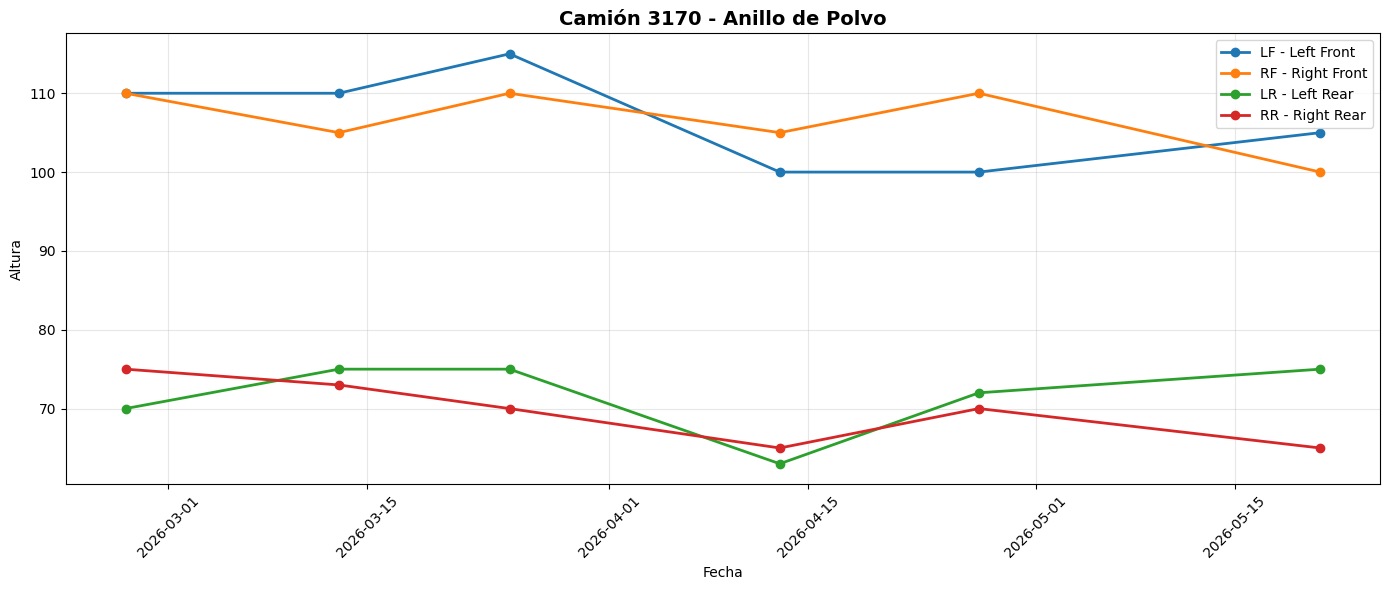

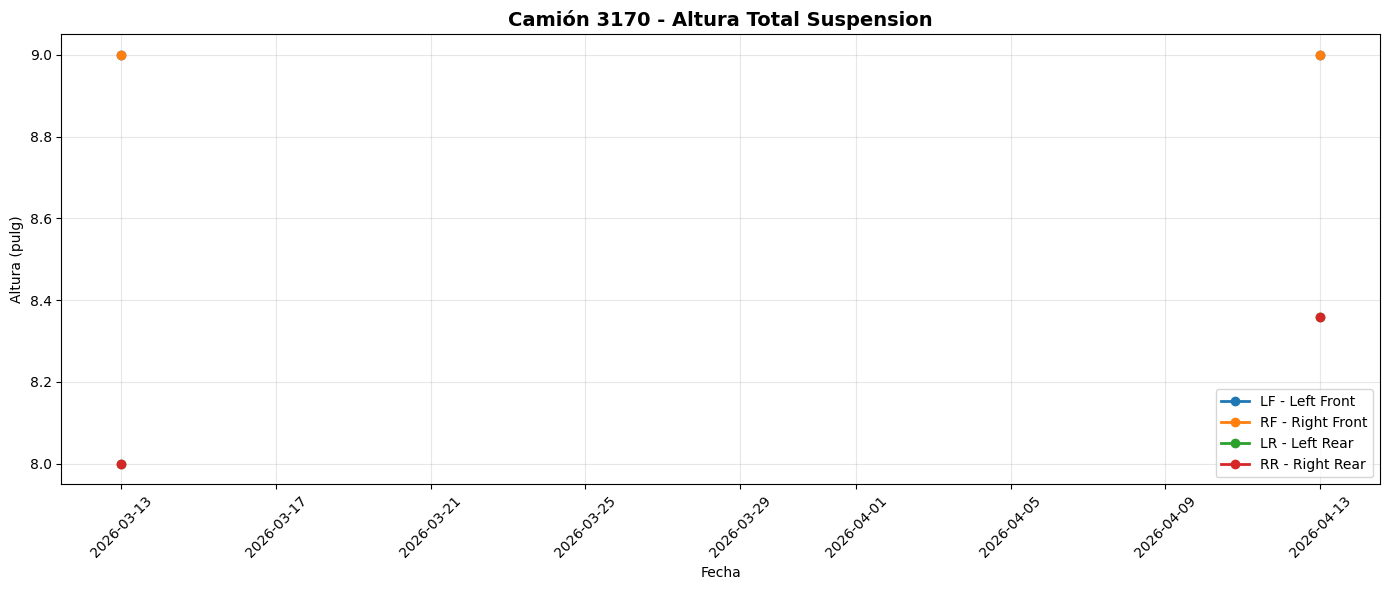

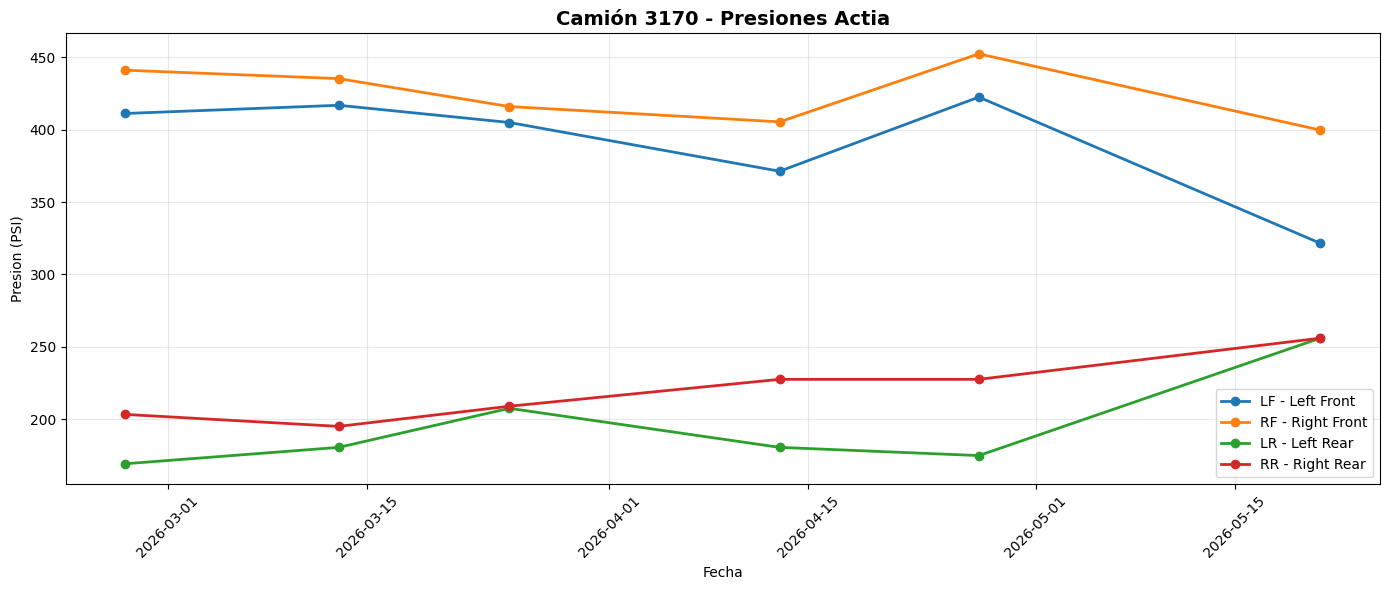

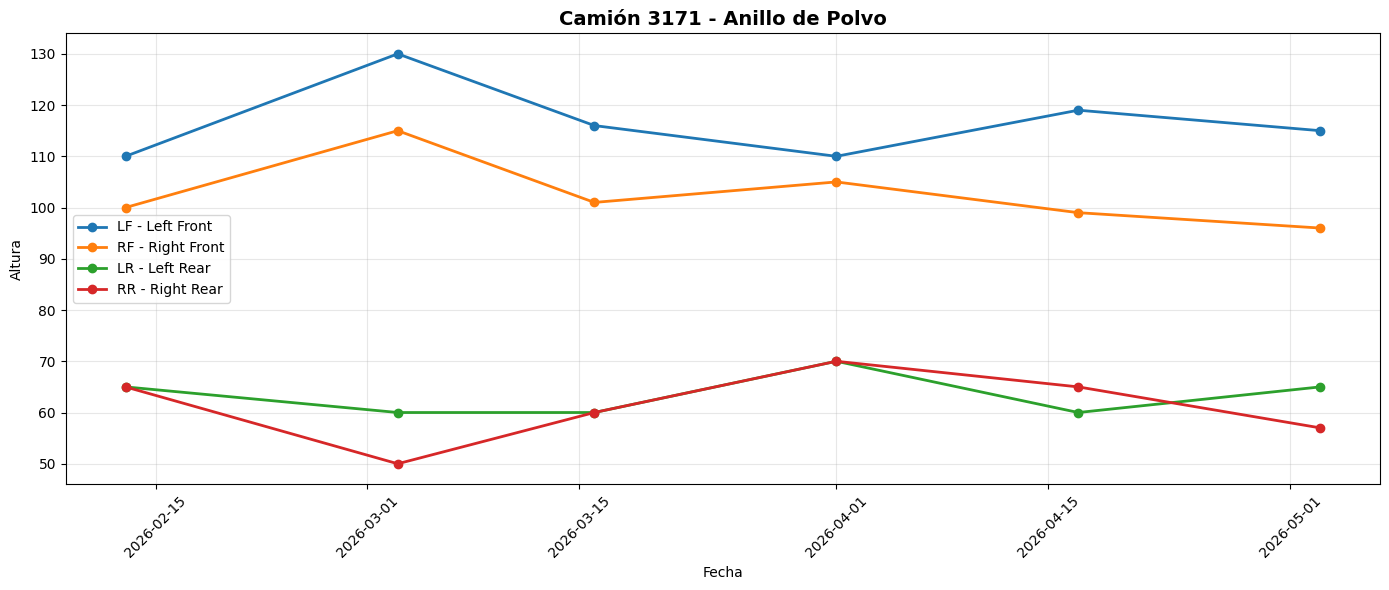

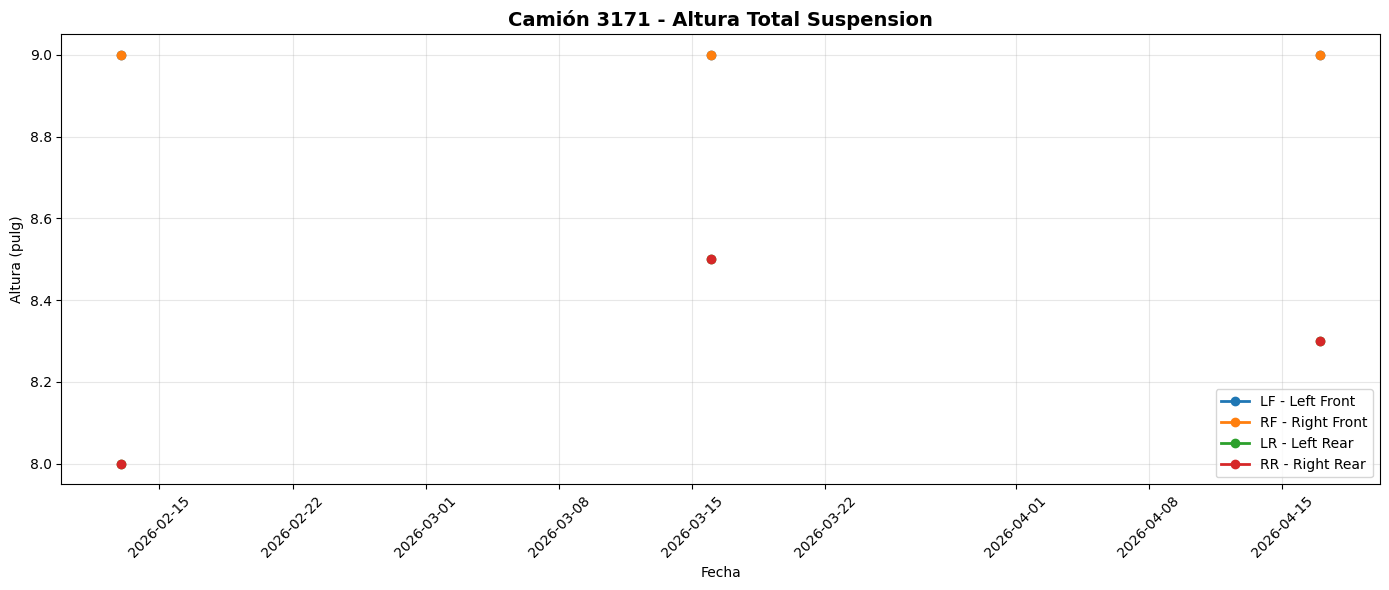

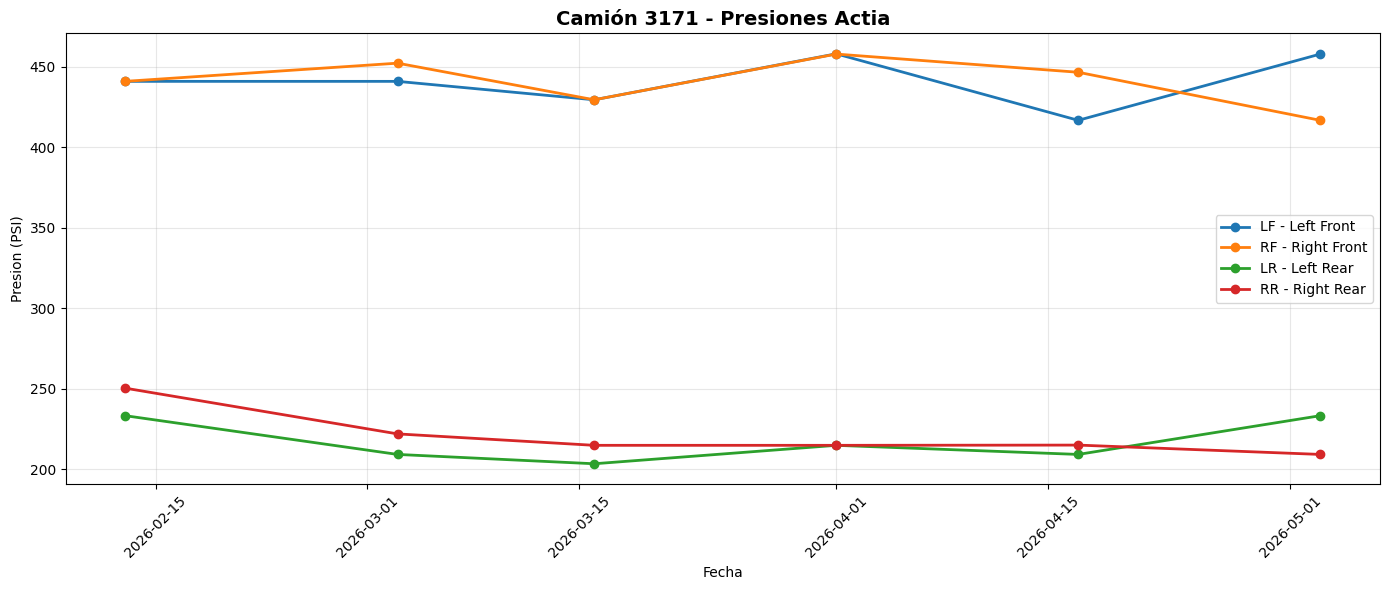

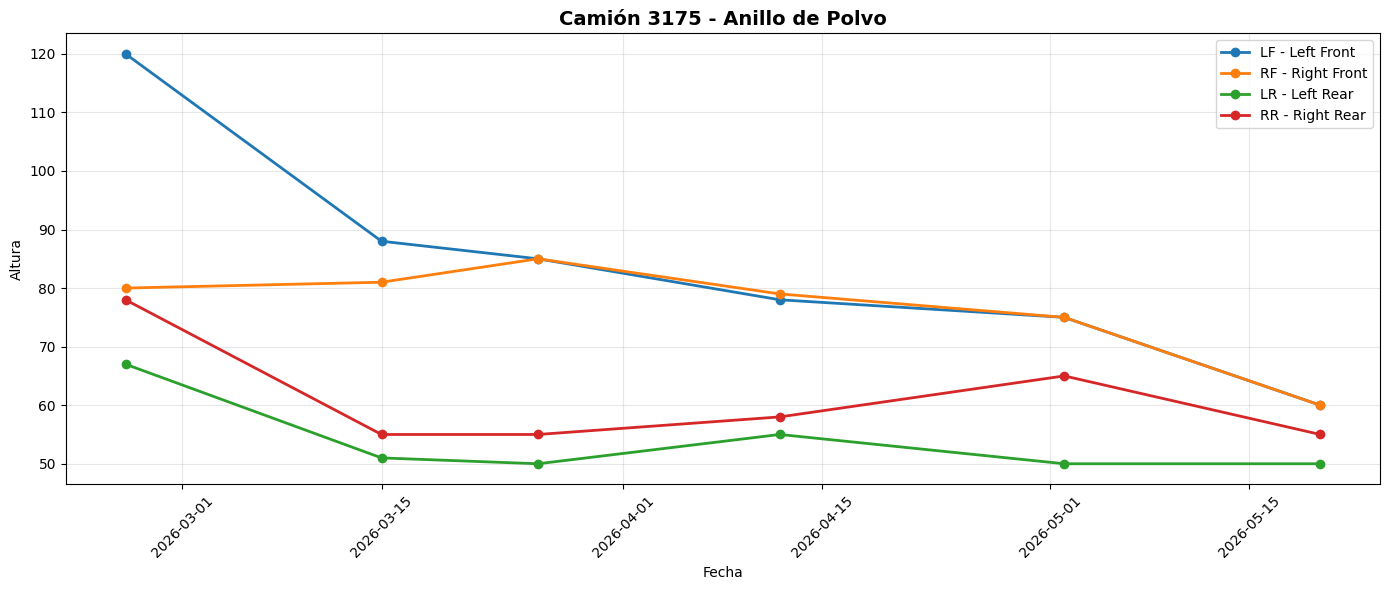

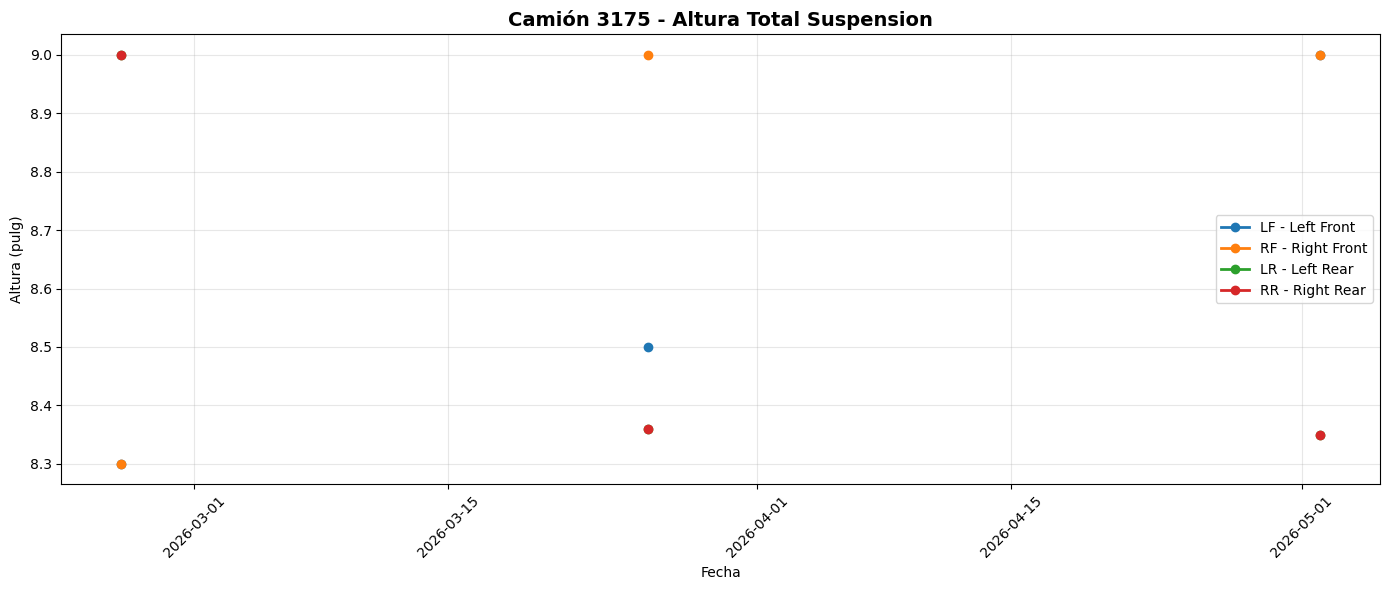

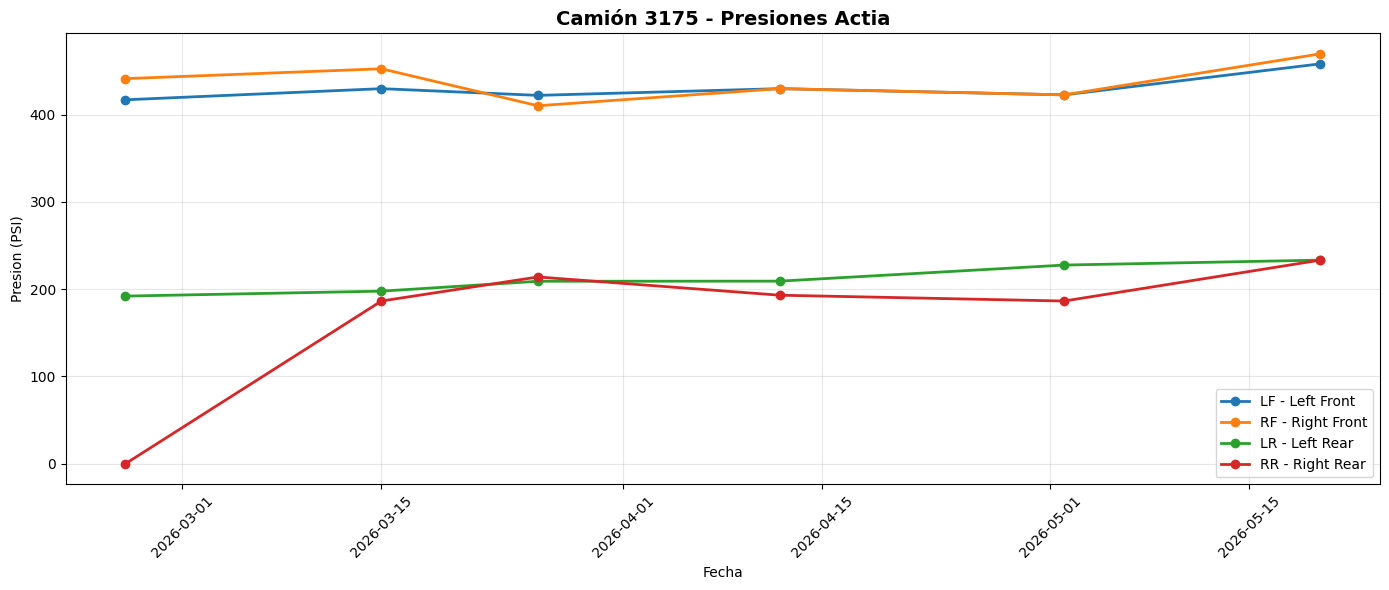

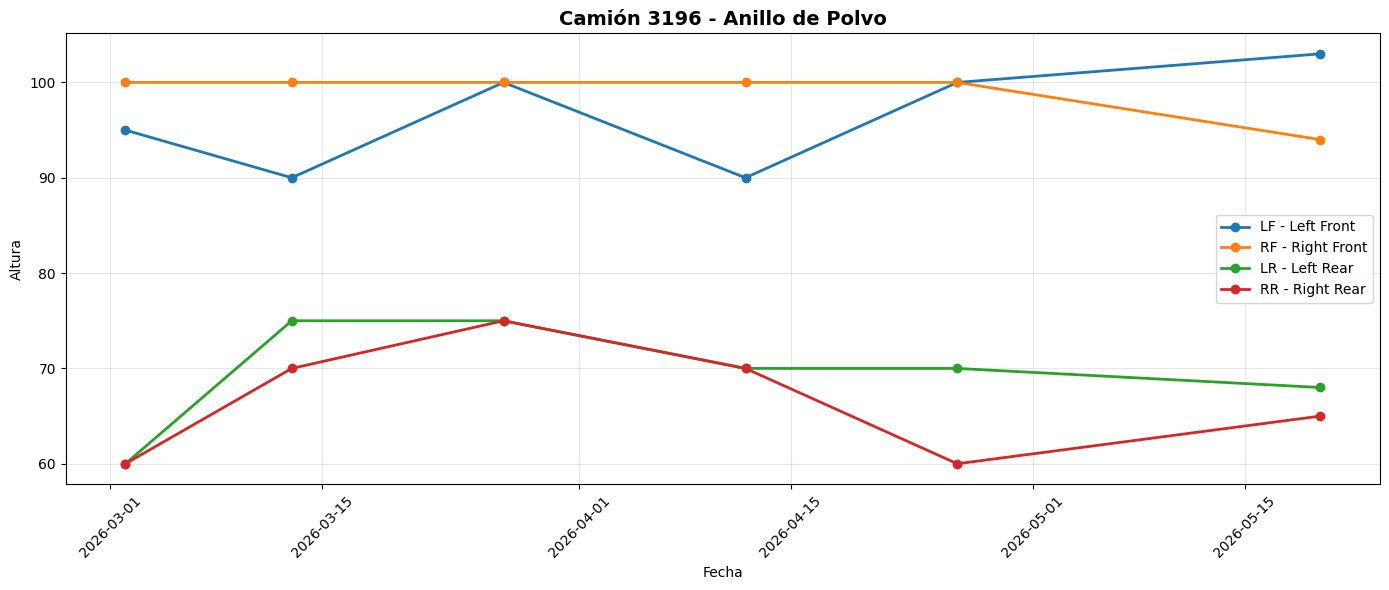

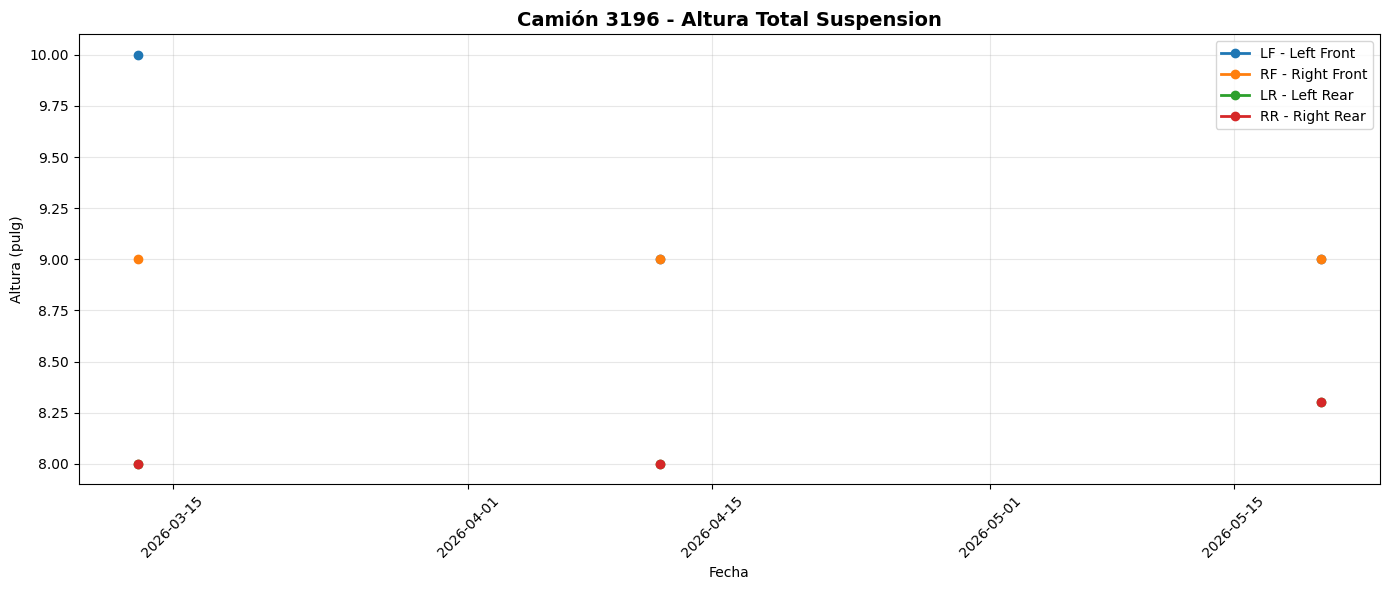

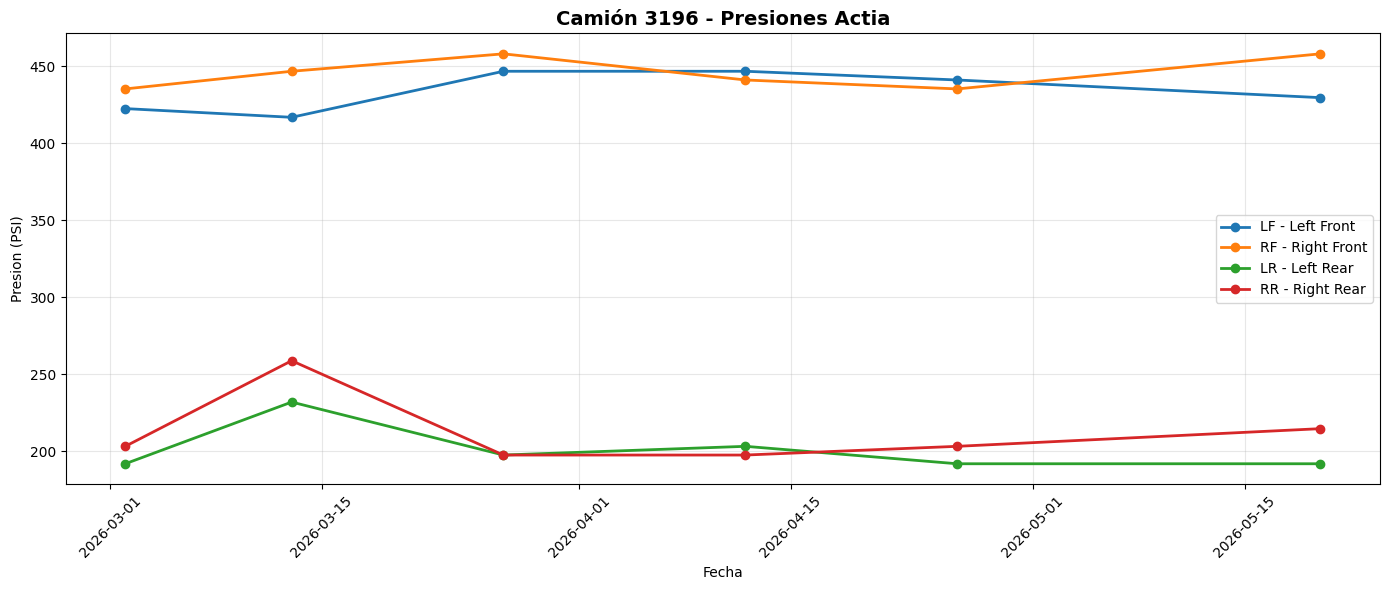

Gráficas generadas correctamente.


In [ ]:
# =========================================================
# FORMATO FECHA
# =========================================================
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)

# =========================================================
# ORDENAR
# =========================================================
df = df.sort_values(['Camion', 'Fecha'])

# =========================================================
# CREAR CARPETA
# =========================================================
output_dir = Path("Graficas_Suspension")
output_dir.mkdir(exist_ok=True)

# =========================================================
# CONFIGURACION GRAFICAS
# =========================================================
graficas = {

    'AP': {
        'cols': ['AP LF', 'AP RF', 'AP LR', 'AP RR'],
        'titulo': 'Anillo de Polvo',
        'ylabel': 'Altura'
    },

    'AT': {
        'cols': ['AT LF', 'AT RF', 'AT LR', 'AT RR'],
        'titulo': 'Altura Total Suspension',
        'ylabel': 'Altura (pulg)'
    },

    'PA': {
        'cols': ['PA LF', 'PA RF', 'PA LR', 'PA RR'],
        'titulo': 'Presiones Actia',
        'ylabel': 'Presion (PSI)'
    }
}

# =========================================================
# NOMBRES
# =========================================================
labels = {
    'LF': 'LF - Left Front',
    'RF': 'RF - Right Front',
    'LR': 'LR - Left Rear',
    'RR': 'RR - Right Rear'
}

# =========================================================
# GRAFICAR POR CAMION
# =========================================================
for camion in df['Camion'].unique():

    df_camion = df[df['Camion'] == camion].copy()

    for key, info in graficas.items():

        plt.figure(figsize=(14,6))

        for col in info['cols']:

            posicion = col.split()[-1]

            plt.plot(
                df_camion['Fecha'],
                df_camion[col],
                marker='o',
                linewidth=2,
                label=labels[posicion]
            )

        plt.title(
            f'Camión {camion} - {info["titulo"]}',
            fontsize=14,
            fontweight='bold'
        )

        plt.xlabel('Fecha')
        plt.ylabel(info['ylabel'])

        plt.xticks(rotation=45)

        plt.grid(True, alpha=0.3)

        plt.legend()

        plt.tight_layout()

        # guardar
        nombre = output_dir / f'{camion}_{key}.png'

        plt.savefig(nombre, dpi=300)

        plt.show()

        plt.close()

# =========================================================
# FINAL
# =========================================================
print("Gráficas generadas correctamente.")